
<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/11-Instrumental_Variables.ipynb)

</div>

$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE -- INSTRUMENTAL VARIABLES}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{Nov 7, 2025}\\\\\\
\end{array}
$$

---

**Goals:**

1. Define Instrumental Variables (IVs)
2. Assumptions of IVs
3. Estimation of IVs
4. Application of IVs

# Motivating Example: War Participation and Depression

- **Goal:** We want to estimate the *causal effect* of War Participation ($S$) on Depression ($Y$):

    $$
    Y = \beta_0 + \beta_1 \cdot S + \varepsilon
    $$

    Here, $\beta_1$ represents how much depression changes, on average, when a person participates in war compared to when they do not.

- **Problem:** War Participation ($S$) is correlated with other factors that also influence Depression ($Y$). As a result, $S$ and the error term $\varepsilon$ move together:

    $$
    \text{Cov}(S, \varepsilon) \neq 0 , \qquad S \not\!\perp\!\!\!\perp U
    $$

    - **Why is that the case?** Because some of the reasons people go to war are the same reasons that might affect their mental health later on. For example:
    
        1. **Health:** People who are medically fit are more likely to serve and may experience different mental health outcomes.
        2. **Motivation:** Individuals who are highly motivated or patriotic may choose to enlist and may also cope with stress differently.
        3. **Socioeconomic Background:** Wealthier individuals could avoid being drafted through college deferments and may have better access to mental health resources later.

    These factors are not included in the regression, so they become part of the error term $\varepsilon$. Since they influence both War Participation ($S$) and Depression ($Y$), the relationship we estimate using ordinary regression would mix correlation with causation.

## Workaround: Instrumental Variables

- The error term $\varepsilon$ contains all the *unobserved determinants* of Depression (our outcome $Y$) — factors that affect $Y$ but are not explicitly modeled or observed, such as pre-existing trauma, motivation, or socioeconomic status:

    $$
    \varepsilon = \varepsilon_{\text{health}} + \varepsilon_{\text{motivation}} + \varepsilon_{\text{socioeconomic}} + \varepsilon_{\text{other}}
    $$

- If some of the determinants of War Participation (e.g., health or motivation) also influence Depression, then those unobserved factors implicitly enter the error term $\varepsilon$. This makes the treatment variable $S$ (War Participation) correlated with the error term:

    $$
    \text{Cov}(S, \varepsilon) \neq 0
    $$

**Key Problem:** Because factors such as health, motivation, and socioeconomic background affect both War Participation ($S$) and Depression ($Y$), $S$ and $\varepsilon$ are correlated. As a result, an ordinary least squares (OLS) estimate of $\beta_1$ in

$$
Y = \beta_0 + \beta_1 S + \varepsilon
$$

would be biased — it would mix up the true causal effect of war participation with the influence of unobserved characteristics.

**Instrumental Variables (IV) Solution:** To fix this, we introduce an *instrument* $Z$ — the **Draft Number** — which provides random (or exogenous) variation in War Participation that is uncorrelated with $\varepsilon$. This allows us to isolate the portion of $S$ that is driven purely by the draft lottery, not by personal or socioeconomic factors.

### Idea of Instrumental Variables

An **Instrumental Variable (IV)** helps us estimate causal effects when the treatment variable ($S$) is correlated with unobserved factors ($\varepsilon$).  
The IV provides *exogenous variation* in the treatment — variation that is effectively random — allowing us to isolate the causal relationship between $S$ and $Y$.

---

![alt text](War_Depression.png "War_Depression")

An **Instrumental Variable (IV)** ($Z$) is a variable that helps identify causal effects by providing random (exogenous) variation in the treatment ($S$). For $Z$ to be a *valid instrument*, it must satisfy three key assumptions:

---

#### Key Assumptions for a Valid Instrument

1. **Exogeneity (Exclusion Restriction):**  
   The instrument $Z$ must be **uncorrelated** with the unobserved factors that affect the outcome ($Y$). This means $Z$ influences $Y$ only *through* its effect on $S$, not directly.
   $$
   U \perp Z \quad \text{and} \quad V \perp Z
   $$
   or equivalently,
   $$
   \text{Cov}(Z, \varepsilon) = 0
   $$


2. **Relevance:**  
   The instrument $Z$ must have a **non-zero effect** on the treatment $S$. In other words, $Z$ should change the likelihood of receiving the treatment, at least for some individuals in the population.

   This can be expressed in two equivalent ways:
   $$
   S(Z=1, V) \neq S(Z=0, V) \quad \text{for some } V
   $$
   or, in covariance form:
   $$
   \text{Cov}(Z, S) \neq 0
   $$

   This ensures that the instrument provides *meaningful variation* in $S$ — otherwise, it cannot explain any causal effect.


3. **Monotonicity:**  
   The instrument must affect the treatment in the **same direction** for everyone. It cannot make some people *more* likely and others *less* likely to receive treatment.  
   $$
   S(Z=1, V) \geq S(Z=0, V) \quad \text{for all } V
   $$
   This assumption rules out “defiers” — individuals who would do the opposite of what the instrument encourages.

---

**Summary**

| Assumption | Meaning | Formal Expression |
|-------------|----------|------------------|
| **Exogeneity** | Instrument affects $Y$ only through $S$ | $\text{Cov}(Z, \varepsilon) = 0$ |
| **Relevance** | Instrument is correlated with the treatment | $\text{Cov}(Z, S) \neq 0$ and $S(Z=1, V) \neq S(Z=0, V)$ |
| **Monotonicity** | Instrument moves treatment in one direction only | $S(Z=1, V) \geq S(Z=0, V)$ |

---

These assumptions together ensure that the variation in $S$ induced by $Z$ is **both exogenous and meaningful**, allowing us to identify a causal effect — the Local Average Treatment Effect (LATE).

**Example: Draft Lottery and War Participation**

| Concept | Variable | Description |
|----------|-----------|--------------|
| **Instrument ($Z$)** | Draft Number | Randomly assigned in the Vietnam War; determines likelihood of being drafted. |
| **Treatment ($S$)** | War Participation | Whether an individual served in the war. |
| **Outcome ($Y$)** | Depression | Post-war mental health outcomes. |

- The draft number ($Z$) affects whether someone participates in the war ($S$).  
- It has **no direct effect** on depression ($Y$) except through war participation.  

Therefore, the draft number provides random variation in $S$, allowing us to identify the causal effect of war participation on depression.

---

**Intuition**

The instrumental variable isolates the *random part* of war participation that comes purely from the draft lottery.  
By using this random variation, we can estimate how participating in the war causally affects depression — free from the influence of confounding factors like health, motivation, or socioeconomic background.

## Estimating the IV

There are three main ways to estimate the effect of an instrumental variable (IV).  
The first — and most common — is the **Two-Stage Least Squares (TSLS)** approach.

### 1) Two-Stage Least Squares (TSLS) Approach

**Stage 1: Regressing the Instrument on the Treatment**

**TSLS Solution:**  
To address the bias caused by the correlation between $S$ (War Participation) and $\varepsilon$ (unobserved factors affecting Depression), we use an instrument $Z$ — the *Draft Number* — which provides random variation in $S$ that is uncorrelated with $\varepsilon$.

In the **first stage** of TSLS, we estimate how the instrument affects the treatment:

$$
S = \pi_0 + \pi_1 Z + V, \qquad \text{or} \qquad \text{War} = \pi_0 + \pi_1 \cdot (\text{Draft\#}) + V
$$

This regression gives us the predicted (fitted) values of $S$: 

$$
\widehat{S} = \pi_0 + \pi_1 Z, \qquad \text{or} \qquad \widehat{\text{War}} = \pi_0 + \pi_1 \cdot (\text{Draft\#})
$$

The predicted component $\widehat{S}$ represents only the variation in War Participation that comes from the random draft lottery — that is, the *exogenous* component of $S$.  
Under the assumption that the instrument $Z$ is exogenous, the predicted treatment $\widehat{S}$ is uncorrelated with the unobserved determinants of Depression:

$$
\text{Cov}(\widehat{S}, \varepsilon) = 0
$$

**Interpretation:**  
$\widehat{S}$ captures the part of War Participation explained by the draft lottery, unlike the parts driven by motivation, health, or socioeconomic factors. This exogenous variation in $\widehat{S}$ will be used in the second stage to identify the causal effect of War Participation on Depression.

---

**Stage 2: Regressing the Outcome on the Predicted Treatment**

In the **second stage** of TSLS, we take the predicted values $\widehat{S}$ from Stage 1 and use them in place of the original treatment variable $S$ in the outcome equation:

$$
Y = \beta_0 + \beta_1 \widehat{S} + u , \qquad \text{or} \qquad \text{Depression} = \beta_0 + \beta_1 \cdot \widehat{\text{War}} + u
$$

Here, $u$ is a new composite error term that is uncorrelated with $\widehat{S}$ by virtue of the instrument’s exogeneity.

**Interpretation:**
- By regressing Depression ($Y$) on $\widehat{S}$, we isolate only the variation in War Participation that is *predicted by the random draft lottery*.  
- This ensures that the variation attributed to $\widehat{S}$ is exogenous — not driven by confounding factors such as health, motivation, or socioeconomic background.  
- As a result, the estimated coefficient $\widehat{\beta_1}$ can be interpreted as the **causal effect** of War Participation ($S$) on Depression ($Y$).

### 2) Wald Estimator

The **Wald Estimator** is a simpler, closed-form version of the IV estimator. It applies when both the instrument ($Z$) and the treatment ($S$) are **binary variables** — for example, when:
- $Z =$ 1 if an individual was *drafted* (low draft number), and 0 otherwise.
- $S =$ 1 if an individual *served in the war*, and 0 otherwise.

Under these conditions, the IV (causal) effect can be estimated as the ratio of two covariances:

$$
\widehat{\beta_1}^{IV} = \frac{\text{Cov}(Z, Y)}{\text{Cov}(Z, S)}
$$

or equivalently, as a ratio of differences in group means:

$$
\widehat{\beta_1}^{IV} =
\frac{E[Y \mid Z = 1] - E[Y \mid Z = 0]}
     {E[S \mid Z = 1] - E[S \mid Z = 0]}
$$

**Interpretation:**
- **Numerator:** How the *instrument* ($Z$) changes the outcome ($Y$) -- how average Depression differs between those with low vs. high draft numbers.
- **Denominator:** How the instrument affects the *treatment* ($S$) -- how much more likely those with low draft numbers are to serve in the war.
- **Ratio:** Gives the **average causal effect** of serving in the war ($S$) on Depression ($Y$) among individuals whose service status was influenced by the draft lottery.

This estimate corresponds to the **Local Average Treatment Effect (LATE)** — the causal effect for the subset of people (the *compliers*) who served **only because** they were drafted.

# Example: The effect of watching sesame street on later academic achievement.

<img src="https://www.aeaweb.org/content/file?id=8888.png?raw=true" width="500" height="auto" />



**Research Question**

> Does watching Sesame Street ($S$) have a positive impact on later academic achievement ($Y$)?


**Model Setup**

\begin{aligned}
S & =\left\{\begin{array}{l}
1 \text { if watched Sesame }  \\
0 \text { did not watched Sesame}
\end{array}\right. \\
Y(S, U) & =\text {Score on a literacy test} \\
U & =\text { other determinants of } Y,
\end{aligned}

where $U$ represents other determinants of $Y$ (e.g., socio-economic status).


**The challenge**


$$S \not\!\perp\!\!\!\perp U,$$

as various family and individual factors likely influence whether a child watches the program $S$ and the child's later academic outcomes ($Y$).

> It's difficult to isolate the effect of watching Sesame Street on academic achievement from unobserved confounders, such as socio-economic status. These unobserved factors may influence both:
+  a child's likelihood of watching the program and
+ their academic outcomes,

leading to biased estimates.


**Solution?**

Introduce an instrumental variable —**encouragement** $Z$ —which we can control and randomize. In this context, encouragement refers to providing children with additional information or motivational support to watch Sesame Street. This approach aligns with the original proposal by [Ball & Bogatz (1970)](https://files.eric.ed.gov/fulltext/ED068155.pdf), who explored the impact of such encouragement on children's engagement with educational media.


\begin{aligned}
Z & =\left\{\begin{array}{l}
1 \text { if encouraged  }  \\
0 \text { not encouraged}
\end{array}\right. \\
\end{aligned}


Our IV allows us to estimate the causal effect of watching Sesame Street on academic achievement for a specific subgroup: the **compliers**, or those whose likelihood of watching the program is influenced by the encouragement $Z$.

> How does watching Sesame Street $S$ impact academic achievement $Y$ for children whose likelihood of watching the program is influenced by the encouragement $Z$?

**Data:**
- **`encour`**: Indicator variable for whether the child was encouraged to watch Sesame Stree. Instrument $Z$.
- **`watched`**: Indicator variable for whether the child actually watched Sesame Street. Treatment $S$.
- **`letters`**: Score on a literacy test. Outcome $Y$.
- **`age`**: Age of the child (in months), included as a control variable.
- **`female`**: Indicator variable for gender (female), included as a control variable.
- **`Other variables`**: Various additional factors.


In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

from matplotlib.colors import LinearSegmentedColormap
from scipy import stats


sesame = pd.read_csv("sesame.csv")
sesame.head()

,rownames,id,site,sex,age,viewcat,setting,viewenc,prebody,prelet,...,encour,_Isite_2,_Isite_3,_Isite_4,_Isite_5,regular,watched,encouraged,y,pretest
0,1,1,1,1,66,1,2,1,16,23,...,1,0,0,0,0,0,0,1,30,23
1,2,2,1,2,67,3,2,1,30,26,...,1,0,0,0,0,1,1,1,37,26
2,3,3,1,1,56,3,2,2,22,14,...,0,0,0,0,0,1,1,0,46,14
3,4,4,1,1,49,1,2,2,23,11,...,0,0,0,0,0,0,0,0,14,11
4,5,5,1,1,69,4,2,2,32,47,...,0,0,0,0,0,1,1,0,63,47


In [2]:
sesame.columns

Index(['rownames', 'id', 'site', 'sex', 'age', 'viewcat', 'setting', 'viewenc',
       'prebody', 'prelet', 'preform', 'prenumb', 'prerelat', 'preclasf',
       'postbody', 'postlet', 'postform', 'postnumb', 'postrelat', 'postclasf',
       'peabody', 'agecat', 'encour', '_Isite_2', '_Isite_3', '_Isite_4',
       '_Isite_5', 'regular', 'watched', 'encouraged', 'y', 'pretest'],
      dtype='object')

In [3]:
sesame.describe()[['watched', 'encouraged']]

,watched,encouraged
count,240.000000,240.000000
mean,0.775000,0.633333
std,0.418455,0.482902
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


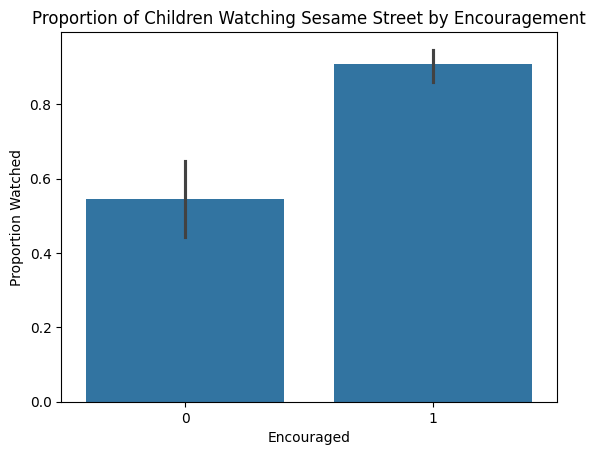

In [4]:
sns.barplot(x=sesame['encour'], y=sesame['watched'])
plt.title('Proportion of Children Watching Sesame Street by Encouragement')
plt.xlabel('Encouraged')
plt.ylabel('Proportion Watched')
plt.show()

Observe that children who were encouraged to watch the show had a notably higher proportion of viewers compared to those who were not encouraged. This difference suggests that ${\tt encouragement}$ effectively increases the likelihood of viewing Sesame Street.

### Instrument Assumptions

How plausible is `encouragement` as an instrument?

#### 1) Exogeneity

   $$
   U \perp Z \quad \text{and} \quad V \perp Z
   $$
   or equivalently,
   $$
   \text{Cov}(Z, \varepsilon) = 0
   $$

We test whether encouragement is randomly assigned across relevant variables, ensuring balance between the encouraged and non-encouraged groups.

In [5]:
# List of variables to test for balance
variables_to_test = ['age', 'sex', 'pretest']

# Perform t-tests for each variable
for var in variables_to_test:

    # Split the data by encouragement status
    group_1 = sesame[sesame['encouraged'] == 1][var]
    group_0 = sesame[sesame['encouraged'] == 0][var]

    # Perform the t-test to compare means
    t_stat, p_value = stats.ttest_ind(group_1, group_0, equal_var=False)

    # Print results
    print(f'Test for {var}:')
    print(f'T-statistic: {t_stat:.4f}, p-value: {p_value:.4f}')
    print('---')

    # Interpretation
    if p_value < 0.05:
        print(f"  Significant difference in {var}, suggests imbalance.\n")
    else:
        print(f"  No significant difference in {var}, supports balance.\n")


Test for age:
T-statistic: -0.3590, p-value: 0.7200
---
  No significant difference in age, supports balance.

Test for sex:
T-statistic: -0.3115, p-value: 0.7557
---
  No significant difference in sex, supports balance.

Test for pretest:
T-statistic: -1.4258, p-value: 0.1561
---
  No significant difference in pretest, supports balance.



#### 2) Relevance

   This can be expressed in two equivalent ways:
   $$
   S(Z=1, V) \neq S(Z=0, V) \quad \text{for some } V
   $$
   or, in covariance form:
   $$
   \text{Cov}(Z, S) \neq 0
   $$

For the instrument to be relevant, it must be correlated with $S$ -- watching Sesame Street. Meaning that encouragement to watch Sesame Street has to actually make some kids more likely to watch it.

$$P(\text{Complier})>0 $$


If the encouragement has no effect—meaning kids are just as likely (or unlikely) to watch Sesame Street whether they’re encouraged or not—then encouragement isn’t a relevant instrument.

+ We test this using a linear regression model.


In [6]:
# Add a constant to the model
sesame['const'] = 1

# Fit a linear regression model (OLS) for relevance
relevance_model = sm.OLS(sesame['watched'], sesame[['const', 'encouraged']]).fit()
print(relevance_model.summary())


                            OLS Regression Results                            
Dep. Variable:                watched   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     50.46
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           1.40e-11
Time:                        14:49:04   Log-Likelihood:                -107.88
No. Observations:                 240   AIC:                             219.8
Df Residuals:                     238   BIC:                             226.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5455      0.041     13.434      0.0

+ The coefficient is 0.3624, meaning that being encouraged to watch Sesame Street increases the likelihood of watching the program by approximately 36.24% compared to those who were not encouraged.
+ Statistical Significance: The p-value for encouraged is 0.000, which is highly significant. This suggests that the encouragement to watch Sesame Street has a statistically significant effect on the outcome.



#### 3) Monotonicity

Monotonicity means that encouragement to watch Sesame Street should only make kids more likely to watch it. So, kids encouraged to watch Sesame Street are either more likely to watch or at least equally likely, but encouragement never makes them watch less.

+ Perform logistic regression to check for monotonicity, which ensures that the instrument  does not induce defiers (children who behave contrary to encouragement):

$$P(\text{Defier})=0 $$

In [7]:
monotonicity_model = sm.Logit(sesame['watched'], sesame[['const', 'encouraged', 'age', 'sex', 'site']]).fit()
print(monotonicity_model.summary())


Optimization terminated successfully.
         Current function value: 0.389264
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                watched   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Fri, 07 Nov 2025   Pseudo R-squ.:                  0.2699
Time:                        14:49:07   Log-Likelihood:                -93.423
converged:                       True   LL-Null:                       -127.96
Covariance Type:            nonrobust   LLR p-value:                 3.564e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9288      1.841      1.048      0.295      -1.679       5.537
encouraged     2.5268      0.

+ Encouragement has a significant positive effect on the likelihood of watching Sesame Street ($p < 0.05$).
+ Age, sex, and site have less impact, which supports monotonicity.

Overall, our instrument seems pretty plausible!

### Compliance Types

Let's further categorized our population of interest!

The population can be divided into four groups based on how they respond to the instrument $Z$:

1. **Compliers**: These individuals comply with the instrument. They take the treatment when $Z = 1$, but not when $Z = 0$.  
   $$ S(Z=1, V) = 1 \quad \text{and} \quad S(Z=0, V) = 0 $$

2. **Always-takers**: These individuals always take the treatment, regardless of the instrument $Z$.  
   $$ S(Z=1, V) = S(Z=0, V) = 1 $$

2. **Never-takers**: These individuals never take the treatment, regardless of the instrument $Z$.  
   $$ S(Z=1, V) = S(Z=0, V) = 0 $$

4. **Defiers**: These individuals do the opposite of what the instrument suggests. They take the treatment when $Z = 0$, but not when $Z = 1$.  
   $$ S(Z=1, V) = 0 \quad \text{and} \quad S(Z=0, V) = 1 $$

- **Compliers**: Watch Sesame Street only if encouraged.
- **Always-takers**: Watch Sesame Street regardless of encouragement.
- **Never-takers**: Do not watch Sesame Street regardless of encouragement.
- **Defiers**: Behave contrary to the encouragement (assumed to not exist due to monotonicity).

In [8]:
# Calculate proportions for each group
d_z_1 = sesame.loc[sesame['encour'] == 1, 'watched'].mean()
d_z_0 = sesame.loc[sesame['encour'] == 0, 'watched'].mean()

proportion_compliers = d_z_1 - d_z_0
proportion_always_takers = d_z_0
proportion_never_takers = 1 - d_z_1

# Assuming no Defiers
proportion_defiers = 0

In [9]:
proportion_compliers

np.float64(0.3624401913875599)

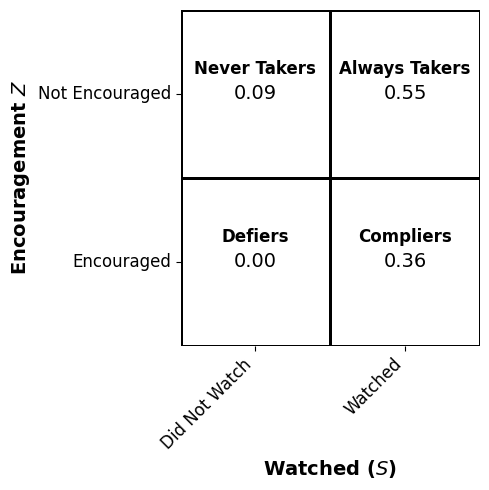

In [10]:
# Create the crosstab data directly
crosstab_data = pd.DataFrame({
    'Encouraged': ['Not Encouraged', 'Not Encouraged', 'Encouraged', 'Encouraged'],
    'Watched': ['Did Not Watch', 'Watched', 'Did Not Watch', 'Watched'],
    'Proportion': [proportion_never_takers, proportion_always_takers, proportion_defiers, proportion_compliers]
}).pivot(index='Encouraged', columns='Watched', values='Proportion')

# Reorder columns and index explicitly
crosstab_data = crosstab_data.reindex(index=['Not Encouraged', 'Encouraged'], columns=['Did Not Watch', 'Watched'])

# Define labels for each box
labels = {
    (0, 0): 'Never Takers',   # Not Encouraged, Did Not Watch
    (0, 1): 'Always Takers',        # Not Encouraged, Watched
    (1, 0): 'Defiers',  # Encouraged, Did Not Watch
    (1, 1): 'Compliers'       # Encouraged, Watched
}

# Plotting
plt.figure(figsize=(5, 5))
heatmap = sns.heatmap(
    crosstab_data,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='black',
    cbar=False,
    cmap=LinearSegmentedColormap.from_list('all_white', ['white', 'white']),
    annot_kws={"size": 14, "color": 'black'}
)

# Customizing the plot
plt.xlabel('Watched ($S$)', fontsize=14, fontweight='bold')
plt.ylabel('Encouragement $Z$', fontsize=14, fontweight='bold')
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=12)

# Add custom labels
for (i, j), label in labels.items():
    plt.text(j + 0.5, i + 0.5 - 0.15, label, ha='center', va='center', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


### Two Ways of Estimating the LATE

#### 1) Via the Two-Stage Least Squares (2SLS) Estimation
This is the practical estimation procedure — the one you’d actually run in software.

1. **First stage**: Regress whether children watched *Sesame Street* ($S$) on the instrument ($Z$), which indicates whether they were encouraged to watch.
   $$
   S = \pi_0 + \pi_1 Z + V
   $$
   This estimates how encouragement affects watching behavior and gives the predicted values:
   $$
   \widehat{S} = \pi_0 + \pi_1 Z
   $$

2. **Second stage**: Regress the outcome (academic performance, $Y$) on the predicted values of $S$ from the first stage.
   $$
   Y = \beta_0 + \beta_1 \widehat{S} + \varepsilon
   $$

In [5]:
first_stage = smf.ols('watched ~ encour', data=sesame).fit()
sesame['predicted_watched'] = first_stage.fittedvalues
second_stage = smf.ols('y ~ predicted_watched', data=sesame).fit()
late_2sls_manual = second_stage.params['predicted_watched']
late_2sls_manual

np.float64(7.933993399339924)

A more direct method is to call `IV2SLS` from `linearmodels` package.


In [11]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [linearmodels] [linearmodels]


In [6]:
import linearmodels as lm

lm.IV2SLS.from_formula('y ~ 1 + [watched ~ encour]', data=sesame).fit().summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:                      y   R-squared:                      0.1355
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1318
No. Observations:                 240   F-statistic:                    2.9570
Date:                Fri, Nov 07 2025   P-value (F-stat)                0.0855
Time:                        16:41:42   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      20.593     3.6811     5.5942     0.0000      13.378      27.808
watched        7.9340     4.6138     1.7196     0.0855     -1.1090      16.977
==============================================================================

Endogenous: watched
Instruments: encour
Robust Covariance (Heteroskedastic)
Debiased: False
"""

#### 2) Via the Wald Estimator ("Covariance Ratio")

$$
\beta_1^{IV} = \frac{Cov(Z,Y)}{Cov(Z,S)}
$$

In [7]:
# Calculate covariance between Z (encouragement) and Y (outcome)
cov_zy = np.cov(sesame['encour'], sesame['y'])[0, 1]

# Calculate covariance between Z (encouragement) and S (watched Sesame Street)
cov_zs = np.cov(sesame['encour'], sesame['watched'])[0, 1]

# Calculate the Wald estimator (IV estimate)
alpha_1_IV = cov_zy / cov_zs
alpha_1_IV


np.float64(7.933993399339933)

##### 2.1 The Difference-in-Means (LATE form)

A special case of the second one, when both Z and S are binary.

$$
\frac{Cov(Z,Y)}{Cov(Z,S)} = \frac{E[Y|Z=1] - E[Y|Z=0] }{E[S|Z=1] - E[S|Z=0]}
$$

- **Numerator:** How much the outcome changes with the instrument.
- **Denominator:** How much the treatment changes with the instrument.
- Their ratio gives the Local Average Treatment Effect (LATE) — the causal effect among compliers.

In [8]:
# Calculate the means based on the value of the instrument Z (encouragement)
mean_y_z1 = sesame.loc[sesame['encour'] == 1, 'y'].mean()
mean_y_z0 = sesame.loc[sesame['encour'] == 0, 'y'].mean()
mean_s_z1 = sesame.loc[sesame['encour'] == 1, 'watched'].mean()
mean_s_z0 = sesame.loc[sesame['encour'] == 0, 'watched'].mean()

# Calculate the Wald estimator (IV estimate)
alpha_1_IV = (mean_y_z1 - mean_y_z0) / (mean_s_z1 - mean_s_z0)
alpha_1_IV


np.float64(7.933993399339932)

For those children who are encouraged to watch Sesame Street and actually end up watching it, their academic achievement (e.g., literacy scores) increases by 7.94 units on average.

### "Reduced Form"

We can estimate the direct effect (ATE) of $Z$ on $Y$: how does the act of encouraging influence the later score performance?

This would be a valid causal estimate as the exogeneity assumption informs us of the independence assumption: $Z \perp U$.

In [15]:
smf.ols('y ~ encour', data=sesame).fit().summary() # you can also try robust sd

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.593
Date:                Fri, 18 Apr 2025   Prob (F-statistic):              0.109
Time:                        06:17:30   Log-Likelihood:                -961.16
No. Observations:                 240   AIC:                             1926.
Df Residuals:                     238   BIC:                             1933.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.9205      1.421     17.536      0.000      22.121      27.720
encour         2.8756      1.786      1.610      0.109      -0.642       6.393
==============================================================================
Omnibus:                       43.130   Durbin-Watson:                   1.269
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.314
Skew:                           0.535   Prob(JB):                     3.88e-05
Kurtosis:                       2.059   Cond. No.                         3.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The act of encouraging kids to watch Sesame Street has a nearly 3-point increase in their test scores! (though the p-value is not particularly small)

#### Remember non-compliance and ITT?

We can re-interpret this setup as the old ATE estimation problem. The treatment of interest, in this case, watching Sesame, cannot be enforced. We can randomize who are asked to watch Sesame Street, but there will be the non-compliance issue that prevents us from deriving ATE (given the always-takers and never-takers).

We have learned that we can change the causal question when there is non-compliance from ATE to Intent-to-Treat (ITT) effect.


The ITT estimates the causal effect of *treatment assignment* on the outcome of interest. Here, the ITT estimates the causal effect of being encouraged to watch Sesame Street on a child’s score on the literacy test.

Hence, the *treatment assignment* can also be framed as an instrumental variable. The direct effect we obtained above can also be thought of as being a ITT estimate.

### Weak Instrument

For **exogeneity**, we can check for the distribution balance for some control variables across different values of instrument $Z$.

For **relevance**, in general, we can check the relationship between $S$ and $Z$. One approach is to look at the first-stage regression.

For **monotonicity**, this assumption is technically untestable. For example, we want to understand whether there are defilers or not in our data. However, we do not observe the counterfactual outcome for each individual (fundamental problem of causal inference). We can still reason about monotonicity based on previous evidence and assess whether this will likely be true for specific problem setup.

In particular, the ***weak instrument*** problem relates to the **relevance** assumption.

For the instrument to be relevant, it must be correlated with $S$ -- watching Sesame Street. Meaning that encouragement to watch Sesame Street has to actually make some kids more likely to watch it.

$$P(\text{Complier})>0 $$


We only require the proportion of compliers to be greater than $0$. This will still be true when the number is small or close to $0$, which gives us a weak instrument. It will blow up our estimator as the denominator of Cov$(S, Z)$ is small.

Similarly, we can test this with first-stage linear regression of the following form:
$$
S = \beta_0 + \beta_1 Z
$$
Once we fit the model, we can check for the F-statistic or t-statistic as we only have one independent variable in this regression.

In [ ]:
smf.ols('watched ~ encour', data=sesame).fit().summary()

The coefficient is 0.3624, meaning that being encouraged to watch Sesame Street increases the likelihood of watching the program by approximately 36.24% compared to those who were not encouraged.


The F-statistic is 50.46 which is more than the threshold 10 presented in the lecture.

Both p-values for the F/t-statistic are extremely small. Hence, we do not have a weak instrument problem here.



### Instrument with Control

If we have extra observed characteristics, we can control them as part of the IV procedure.

This could potentially make the exogeneity argument stronger via conditional independence.

$$
Z \perp U | C
$$

However, this will impact the parameter estimate as we saw in regression with control. The weights for each controlled subgroup will change to the covariance of $Z$ and $S$ in that group.

$$
\alpha_1^{\text{IV, Cont.}} = E \left[ \frac{\text{Cov}(Z, S | C = c)}{\text{Cov}(Z, S)} \text{LATE}(C = c) \right]
$$

Let's try controlling for two variables `age` and `sex`.


In [19]:
first_stage = smf.ols('watched ~ encour + age + sex', data=sesame).fit()
sesame['predicted_watched'] = first_stage.fittedvalues
second_stage = smf.ols('y ~ predicted_watched + age + sex', data=sesame).fit()
late_2sls_manual = second_stage.params['predicted_watched']
late_2sls_manual

np.float64(8.48202609807269)

In [20]:
# direct method
lm.IV2SLS.from_formula('y ~ 1 + age + sex + [watched ~ encour]', data=sesame).fit().summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:                      y   R-squared:                      0.2077
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1976
No. Observations:                 240   F-statistic:                    25.201
Date:                Fri, Apr 18 2025   P-value (F-stat)                0.0000
Time:                        06:24:08   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -10.571     7.6520    -1.3814     0.1671     -25.568      4.4270
age            0.5505     0.1190     4.6241     0.0000      0.3172      0.7838
sex            1.5620     1.5530     1.0058     0.3145     -1.4818      4.6058
watched        8.4820     4.3245     1.9614     0.0498      0.0062      16.958
==============================================================================

Endogenous: watched
Instruments: encour
Robust Covariance (Heteroskedastic)
Debiased: False
"""

Our estimate is now 8.48 points. Nevertheless, in this **experiment**, we know beforehand that the instrument $Z$ was randomly assigned.